# Bước 6 - Tạo đặc trưng RFM

**Notebook:** `06_feature_rfm.ipynb`  
**Input:** `../data/processed/step5_encoded.csv`  
**Output:** `../data/processed/olist_cleaned.csv`

## Mục tiêu

Tạo bộ đặc trưng RFM ở cấp khách hàng để phục vụ các bước khai phá dữ liệu tiếp theo.

RFM gồm ba chỉ số:
- **Recency:** số ngày từ lần mua gần nhất của khách hàng đến ngày tham chiếu.
- **Frequency:** số đơn hàng duy nhất của khách hàng.
- **Monetary:** tổng giá trị sản phẩm khách hàng đã mua, tính theo `price`.

> **Phạm vi:** Notebook này chỉ tạo đặc trưng RFM. Không xử lý lại missing values, outliers hay encoding của các bước trước.


## Phần 2 - Import thư viện

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')


## Phần 3 - Đọc dữ liệu

Đọc dữ liệu đầu ra của Bước 5 (`step5_encoded.csv`).

In [2]:
input_path = '../data/processed/step5_encoded.csv'

df = pd.read_csv(input_path)
print(f"Đã đọc dữ liệu: {df.shape[0]} dòng, {df.shape[1]} cột")


Đã đọc dữ liệu: 95075 dòng, 59 cột


In [3]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_state_AL,customer_state_AM,customer_state_AP,customer_state_BA,customer_state_CE,customer_state_DF,customer_state_ES,customer_state_GO,customer_state_MA,customer_state_MG,customer_state_MS,customer_state_MT,customer_state_PA,customer_state_PB,customer_state_PE,customer_state_PI,customer_state_PR,customer_state_RJ,customer_state_RN,customer_state_RO,customer_state_RR,customer_state_RS,customer_state_SC,customer_state_SE,customer_state_SP,customer_state_TO,order_status_canceled,order_status_delivered,order_status_invoiced,order_status_processing,order_status_shipped,order_status_unavailable,product_category_encoded
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,73
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,63
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,9
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,64
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,60


## Phần 4 - Kiểm tra dữ liệu đầu vào

Bước RFM cần bốn cột chính: `customer_unique_id`, `order_id`, `order_purchase_timestamp`, `price`. Kiểm tra sự tồn tại và chất lượng của các cột này trước khi tính toán.

In [4]:
required_cols = ['customer_unique_id', 'order_id', 'order_purchase_timestamp', 'price']
missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    raise ValueError(f"Thiếu cột bắt buộc cho RFM: {missing_cols}")

print("Đã có đủ các cột bắt buộc cho RFM.")
print(df[required_cols].head())


Đã có đủ các cột bắt buộc cho RFM.
                 customer_unique_id                          order_id  \
0  7c396fd4830fd04220f754e42b4e5bff  e481f51cbdc54678b7cc49136f2d6af7   
1  af07308b275d755c9edb36a90c618231  53cdb2fc8bc7dce0b6741e2150273451   
2  3a653a41f6f9fc3d2a113cf8398680e8  47770eb9100c2d0c44946d9cf07ec65d   
3  7c142cf63193a1473d2e66489a9ae977  949d5b44dbf5de918fe9c16f97b45f8a   
4  72632f0f9dd73dfee390c9b22eb56dd6  ad21c59c0840e6cb83a9ceb5573f8159   

  order_purchase_timestamp   price  
0      2017-10-02 10:56:33   29.99  
1      2018-07-24 20:41:37  118.70  
2      2018-08-08 08:38:49  159.90  
3      2017-11-18 19:28:06   45.00  
4      2018-02-13 21:18:39   19.90  


In [5]:
print("Shape:", df.shape)
print("Số dòng trùng hoàn toàn:", df.duplicated().sum())
print("Missing ở các cột RFM:")
print(df[required_cols].isna().sum())


Shape: (95075, 59)


Số dòng trùng hoàn toàn: 0
Missing ở các cột RFM:
customer_unique_id          0
order_id                    0
order_purchase_timestamp    0
price                       0
dtype: int64


## Phần 5 - Chuẩn hóa dữ liệu phục vụ RFM

Chuyển `order_purchase_timestamp` sang datetime và đảm bảo `price` là kiểu số. Nếu có dòng thiếu các trường bắt buộc cho RFM thì loại khỏi riêng bước tính RFM, vì không thể xác định khách hàng, đơn hàng, ngày mua hoặc giá trị mua.

In [6]:
df['order_purchase_timestamp'] = pd.to_datetime(
    df['order_purchase_timestamp'],
    errors='coerce'
)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

before_rfm_filter = len(df)
df_rfm_source = df.dropna(subset=required_cols).copy()
after_rfm_filter = len(df_rfm_source)

print("Số dòng trước lọc RFM:", before_rfm_filter)
print("Số dòng sau lọc RFM  :", after_rfm_filter)
print("Số dòng bị loại      :", before_rfm_filter - after_rfm_filter)
print("Kiểu order_purchase_timestamp:", df_rfm_source['order_purchase_timestamp'].dtype)


Số dòng trước lọc RFM: 95075
Số dòng sau lọc RFM  : 95075
Số dòng bị loại      : 0
Kiểu order_purchase_timestamp: datetime64[ns]


In [7]:
print("Price < 0:", (df_rfm_source['price'] < 0).sum())
print("Khoảng ngày mua:")
print("  Từ :", df_rfm_source['order_purchase_timestamp'].min())
print("  Đến:", df_rfm_source['order_purchase_timestamp'].max())


Price < 0: 0
Khoảng ngày mua:
  Từ : 2016-09-04 21:15:19
  Đến: 2018-09-03 09:06:57


## Phần 6 - Xác định ngày tham chiếu

Theo hướng dẫn, ngày tham chiếu (`snapshot_date`) được lấy bằng ngày mua gần nhất trong dữ liệu cộng thêm 1 ngày. Cách này giúp Recency nhỏ nhất là 1 thay vì 0.

In [8]:
snapshot_date = df_rfm_source['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print("Ngày mua gần nhất:", df_rfm_source['order_purchase_timestamp'].max())
print("Ngày tham chiếu  :", snapshot_date)


Ngày mua gần nhất: 2018-09-03 09:06:57
Ngày tham chiếu  : 2018-09-04 09:06:57


## Phần 7 - Kiểm tra số lượng khách hàng và đơn hàng

In [9]:
print("Số dòng giao dịch/sản phẩm:", len(df_rfm_source))
print("Số khách hàng duy nhất   :", df_rfm_source['customer_unique_id'].nunique())
print("Số đơn hàng duy nhất     :", df_rfm_source['order_id'].nunique())


Số dòng giao dịch/sản phẩm: 95075
Số khách hàng duy nhất   : 80332
Số đơn hàng duy nhất     : 82936


## Phần 8 - Tính toán RFM

- `Recency`: số ngày từ lần mua gần nhất của khách hàng đến `snapshot_date`.
- `Frequency`: số đơn hàng duy nhất (`order_id`) của khách hàng.
- `Monetary`: tổng `price` của tất cả sản phẩm khách hàng đã mua.

Dữ liệu gốc có thể có nhiều dòng cho cùng một đơn hàng vì mỗi dòng là một sản phẩm trong đơn. Vì vậy `Frequency` dùng `nunique(order_id)` để không đếm trùng đơn hàng nhiều sản phẩm.

In [10]:
rfm = df_rfm_source.groupby('customer_unique_id').agg(
    Recency=(
        'order_purchase_timestamp',
        lambda x: (snapshot_date - x.max()).days
    ),
    Frequency=(
        'order_id',
        'nunique'
    ),
    Monetary=(
        'price',
        'sum'
    )
).reset_index()

print("Kích thước RFM:", rfm.shape)
rfm.head()


Kích thước RFM: (80332, 4)


,customer_unique_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,116,1,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,119,1,18.90
2,0000f46a3911fa3c0805444483337064,542,1,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,326,1,25.99
4,0004aac84e0df4da2b147fca70cf8255,293,1,180.00


## Phần 9 - Kiểm tra kết quả RFM

In [11]:
rfm[['Recency', 'Frequency', 'Monetary']].describe()

,Recency,Frequency,Monetary
count,80332.000000,80332.000000,80332.000000
mean,245.926281,1.032415,94.235755
std,153.358931,0.205294,78.758317
min,1.000000,1.000000,0.850000
25%,122.000000,1.000000,40.000000
50%,227.000000,1.000000,74.990000
75%,355.000000,1.000000,126.185000
max,729.000000,16.000000,4080.000000


In [12]:
print("Missing trong RFM:")
print(rfm.isna().sum())

print("\nGiá trị nhỏ nhất:")
print("Recency  :", rfm['Recency'].min())
print("Frequency:", rfm['Frequency'].min())
print("Monetary :", rfm['Monetary'].min())

print("\nGiá trị lớn nhất:")
print("Recency  :", rfm['Recency'].max())
print("Frequency:", rfm['Frequency'].max())
print("Monetary :", rfm['Monetary'].max())


Missing trong RFM:
customer_unique_id    0
Recency               0
Frequency             0
Monetary              0
dtype: int64

Giá trị nhỏ nhất:
Recency  : 1
Frequency: 1
Monetary : 0.85

Giá trị lớn nhất:
Recency  : 729
Frequency: 16
Monetary : 4080.0


In [13]:
assert rfm['customer_unique_id'].isna().sum() == 0
assert rfm[['Recency', 'Frequency', 'Monetary']].isna().sum().sum() == 0
assert (rfm['Recency'] >= 0).all()
assert (rfm['Frequency'] > 0).all()
assert (rfm['Monetary'] >= 0).all()

print("Kiểm tra logic RFM: đạt")


Kiểm tra logic RFM: đạt


## Phần 10 - Trực quan hóa phân bố RFM

Biểu đồ giúp kiểm tra nhanh phân bố ba chỉ số. Với dữ liệu thương mại điện tử, `Frequency` và `Monetary` thường lệch phải vì phần lớn khách hàng mua ít, một nhóm nhỏ mua nhiều hoặc chi tiêu cao hơn.

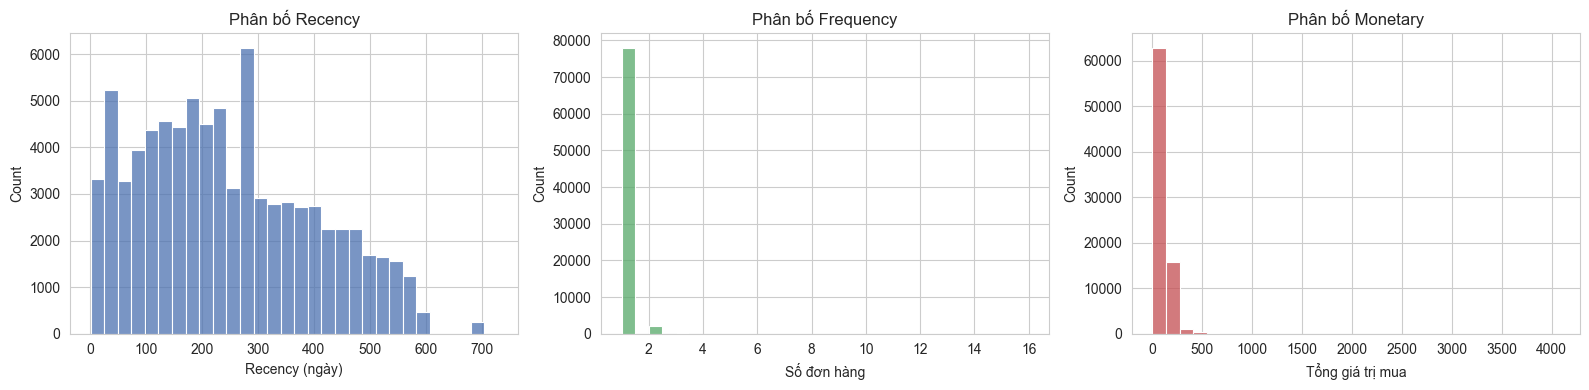

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(rfm['Recency'], bins=30, ax=axes[0], color='#4C72B0')
axes[0].set_title('Phân bố Recency')
axes[0].set_xlabel('Recency (ngày)')

sns.histplot(rfm['Frequency'], bins=30, ax=axes[1], color='#55A868')
axes[1].set_title('Phân bố Frequency')
axes[1].set_xlabel('Số đơn hàng')

sns.histplot(rfm['Monetary'], bins=30, ax=axes[2], color='#C44E52')
axes[2].set_title('Phân bố Monetary')
axes[2].set_xlabel('Tổng giá trị mua')

plt.tight_layout()
plt.show()


## Phần 11 - Diễn giải ý nghĩa

- `Recency` càng nhỏ: khách hàng mua càng gần đây, mức độ tương tác gần hơn.
- `Frequency` càng lớn: khách hàng mua nhiều lần hơn, thể hiện mức độ quay lại cao hơn.
- `Monetary` càng lớn: khách hàng có tổng chi tiêu cao hơn.

Lưu ý: Bước 4 đã loại outlier theo IQR cho `price` và `freight_value`, nên `Monetary` phản ánh nhóm đơn hàng phổ thông sau khi loại các giá trị quá cao theo quy tắc của đề tài.

## Phần 12 - Xuất dataset cuối cùng

Lưu dataset RFM cuối cùng thành `olist_cleaned.csv`. File này là đầu ra của giai đoạn tiền xử lý và là input chính cho clustering/RFM analysis ở các bước tiếp theo.

In [15]:
output_path = '../data/processed/olist_cleaned.csv'

rfm.to_csv(output_path, index=False)

print(f"Đã tạo file RFM cuối cùng: {output_path}")
print(f"Kích thước file output: {rfm.shape}")


Đã tạo file RFM cuối cùng: ../data/processed/olist_cleaned.csv
Kích thước file output: (80332, 4)


## Phần 13 - Nhận xét

- Đã tạo đặc trưng RFM ở cấp `customer_unique_id`.
- `Frequency` được tính bằng số `order_id` duy nhất để tránh đếm trùng các đơn hàng có nhiều sản phẩm.
- `Monetary` được tính bằng tổng `price` theo đúng hướng dẫn của đề tài.
- Dataset `olist_cleaned.csv` đã sẵn sàng cho phân cụm khách hàng, phân tích RFM và các mô hình khai phá dữ liệu tiếp theo.
